# ***Titanic Survival Prediction***
## Machine Learning Project

### Description
This notebook predicts whether a passenger survived the Titanic disaster using machine learning. The project follows the main data science workflow: loading the dataset, exploring the data, cleaning and preprocessing it, creating useful features, training multiple models, evaluating their performance, and testing the model with a new passenger example.

### Dataset
The dataset used in this notebook is the Titanic dataset. It contains passenger information such as age, gender, passenger class, fare, number of family members, and survival status.

### Project Goal
The goal is to build a machine learning model that can predict the `Survived` column, where:

- `0` means the passenger did not survive.
- `1` means the passenger survived.


# **1. Import Libraries**

### Purpose
Import the Python libraries needed for data analysis, visualization, preprocessing, model building, and model evaluation.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.preprocessing
import sklearn.model_selection
import sklearn.linear_model
import sklearn.metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

# **2. Load Dataset**

### Purpose
Load the Titanic dataset into a pandas DataFrame.


In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

# **3. Initial Data Exploration**

### Purpose
Understand the dataset structure before applying machine learning. Check the first rows, shape, columns, data types, missing values, numerical/categorical columns, and duplicate rows.


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [7]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
df.select_dtypes(include=['int64', 'float64']).columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.select_dtypes(include=['object']).columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

# **4. Exploratory Data Analysis (EDA)**

### Purpose
EDA helps to understand the distribution of the data and identify patterns that may affect survival prediction.

## 4.1 Age Distribution
This histogram shows the age distribution of passengers. It helps to understand which age groups were most common on the Titanic.


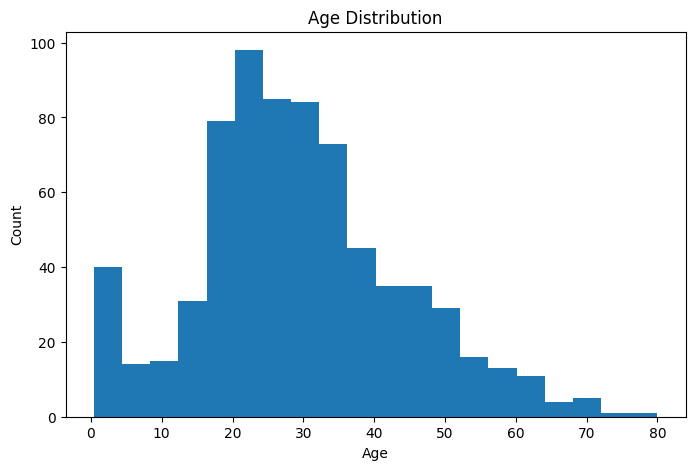

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## **4.2 Fare Distribution**
This histogram shows the distribution of ticket fares. It helps to see whether most passengers paid low, medium, or high fares.


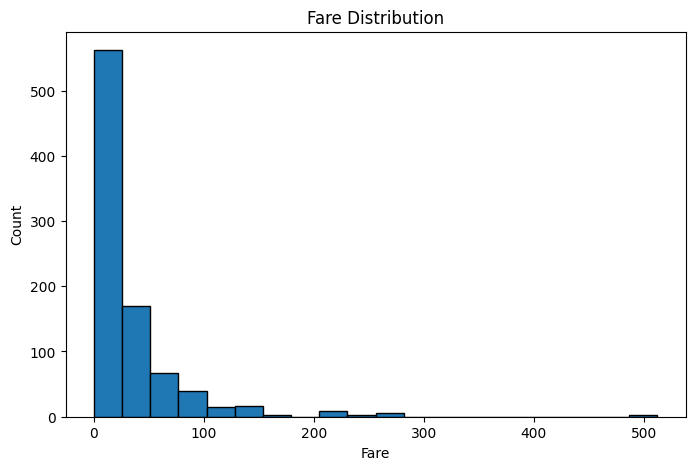

In [13]:
plt.figure(figsize=(8,5))
plt.hist(df["Fare"], bins=20, edgecolor="black")
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

## **4.3 Siblings and Spouses Distribution**
This visualization shows how many siblings or spouses passengers had aboard the Titanic.


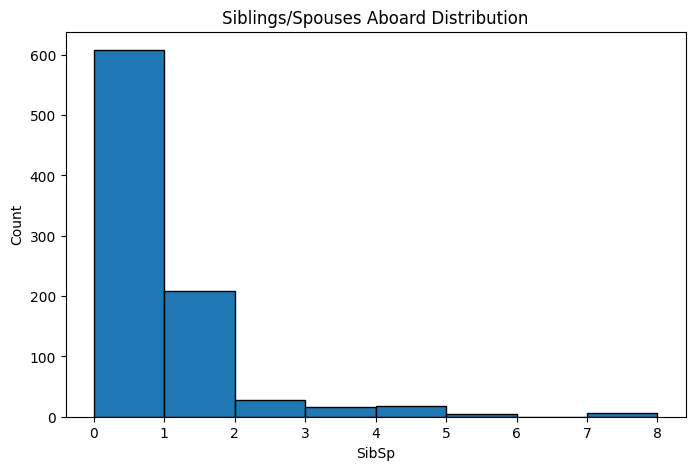

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df["SibSp"], bins=8, edgecolor="black")
plt.title("Siblings/Spouses Aboard Distribution")
plt.xlabel("SibSp")
plt.ylabel("Count")
plt.show()

## **4.4 Survival Distribution**
This bar chart shows the number of passengers who survived and did not survive. It helps to understand the target variable balance.


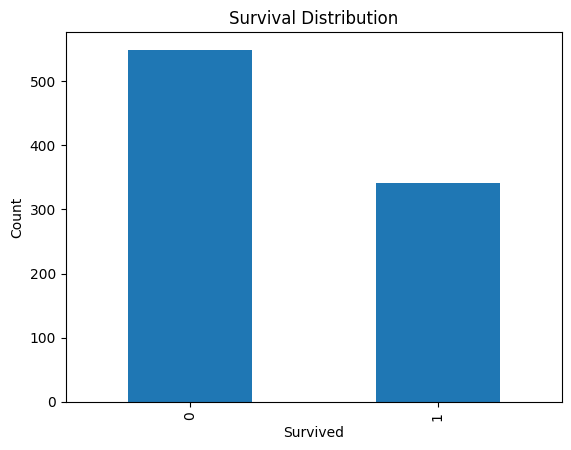

In [15]:
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

## **4.5 Gender Distribution**
This chart shows the number of male and female passengers in the dataset.

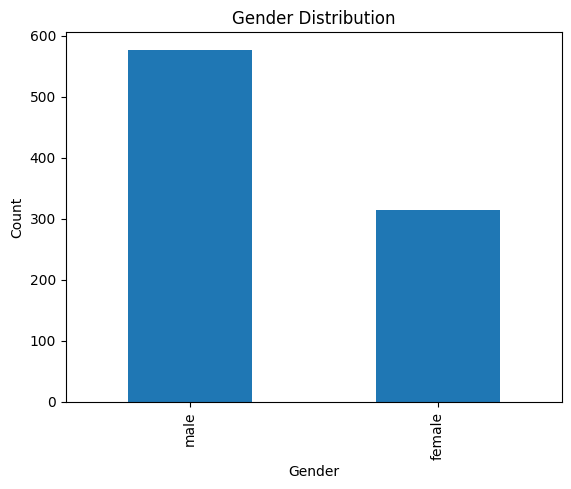

In [16]:
df["Sex"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

## **4.6 Correlation Heatmap**
The correlation heatmap helps identify relationships between numerical features. Stronger correlations may indicate features that are useful for prediction.


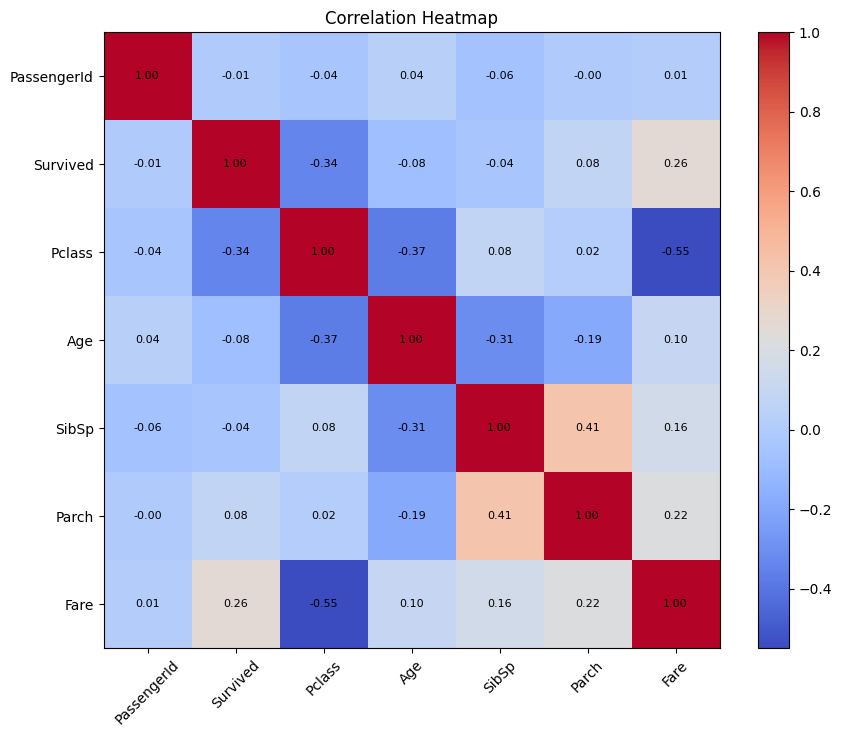

In [17]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))
corr_matrix = numeric_df.corr()
plt.imshow(corr_matrix, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=45)
plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)

# Add numerical values to the heatmap
for i in range(len(numeric_df.columns)):
    for j in range(len(numeric_df.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black", fontsize=8)

plt.title("Correlation Heatmap")
plt.show()

# **5. Feature Engineering**

### Purpose
Feature engineering creates new useful columns from existing data. These new features may improve the model's ability to predict survival.

## 5.1 Family Size
`FamilySize` combines siblings/spouses and parents/children into one feature. 1 is added to include the passenger themselves.


In [18]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

## 5.2 IsAlone
`IsAlone` identifies whether a passenger traveled alone. A value of `1` means the passenger was alone, and `0` means they traveled with family.


In [19]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

## 5.3 Review New Family Features
These cells display the new family-related features to confirm that they were created correctly.


In [20]:
df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [21]:
df[["FamilySize", "IsAlone"]].head()

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


# 6. **Data Preprocessing**

### Purpose
Machine learning models work with numerical and clean data. In this section, categorical columns are encoded into numbers, unnecessary columns are removed, and the dataset is prepared for modeling.

## 6.1 Encode Categorical Features
`Sex` and `Embarked` are categorical columns. Label encoding converts them into numerical values so the machine learning models can use them.


In [22]:
encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])
df["Embarked"] = encoder.fit_transform(df["Embarked"])

## 6.2 Drop Unnecessary Columns
Columns such as `PassengerId`, `Name`, `Ticket`, and `Cabin` are removed because they are either identifiers, text-heavy, or contain many missing values.


In [23]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# **7. Feature Selection**

### Purpose
Separate the dataset into input features `X` and target variable `y`.

- `X` contains the columns used to make predictions.
- `y` contains the survival result we want to predict.


In [24]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [25]:
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0,3,1,22.0,1,0,7.2500,2,2,0
1,1,1,0,38.0,1,0,71.2833,0,2,0
2,1,3,0,26.0,0,0,7.9250,2,1,1
3,1,1,0,35.0,1,0,53.1000,2,2,0
4,0,3,1,35.0,0,0,8.0500,2,1,1


In [26]:
X = df.drop("Survived", axis=1)
y = df["Survived"]



# **8. Train-Test Split**

### Purpose
The dataset is split into training and testing sets. The training set is used to teach the model, while the testing set is used to evaluate how well the model performs on unseen data.


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **9. Logistic Regression Model**

### Purpose
Logistic Regression is a simple and commonly used classification algorithm.


In [28]:
model = LogisticRegression(max_iter=1000)

## 9.1 Data Cleaning Before Training
This cell reloads the dataset and performs the required cleaning steps, including handling missing values, creating engineered features, encoding categorical variables, and dropping unnecessary columns.


In [29]:
df = pd.read_csv("Titanic-Dataset.csv")

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

encoder = LabelEncoder()
df["Sex"] = encoder.fit_transform(df["Sex"])
df["Embarked"] = encoder.fit_transform(df["Embarked"])

df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

X = df.drop("Survived", axis=1)
y = df["Survived"]

In [30]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    891 non-null    int64  
 8   FamilySize  891 non-null    int64  
 9   IsAlone     891 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 69.7 KB


,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
FamilySize,0
IsAlone,0


## 9.2 Train the Logistic Regression Model
The model is trained using the training data so it can learn patterns related to passenger survival.


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## 9.3 Make Predictions
The trained model predicts survival outcomes for the testing data.


In [32]:
y_pred = model.predict(X_test)

## 9.4 Evaluate Accuracy
Accuracy measures the percentage of correct predictions made by the model.


In [33]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7988826815642458


## 9.5 Confusion Matrix
The confusion matrix shows correct and incorrect predictions for each class. It helps us understand where the model is making mistakes.


In [34]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[89 16]
 [20 54]]


# **10. Predicting a New Passenger**

### Purpose
This section tests the trained model using a manually created passenger example. This simulates how the model could be used to predict survival for a new input.


In [35]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])


df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)


encoder = LabelEncoder()
df["Sex"] = encoder.fit_transform(df["Sex"])
df["Embarked"] = encoder.fit_transform(df["Embarked"])


df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

X = df.drop("Survived", axis=1)
y = df["Survived"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7988826815642458


In [36]:
new_passenger = pd.DataFrame([{
    "Pclass": 3,
    "Sex": 1,
    "Age": 25,
    "SibSp": 0,
    "Parch": 0,
    "Fare": 8.05,
    "Embarked": 2,
    "FamilySize": 1,
    "IsAlone": 1
}])

new_passenger = new_passenger.reindex(columns=X.columns, fill_value=0)

prediction = model.predict(new_passenger)

print(prediction)

[0]


# 11. Additional Train-Test Preparation

### Purpose
These cells repeat the train-test split and confirm the shapes of the training and testing datasets before training additional models.


In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 9)
(179, 9)
(712,)
(179,)


In [40]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [41]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 12. Decision Tree Model

### Purpose
A Decision Tree is a classification model that makes decisions by splitting the data based on feature values. It is easy to interpret but can sometimes overfit the training data.


In [43]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

## 12.1 Decision Tree Prediction and Accuracy
The Decision Tree model predicts the test data, and its accuracy is calculated.


In [44]:
tree_pred = tree_model.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

tree_accuracy = accuracy_score(y_test, tree_pred)
print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.7821229050279329


## 12.2 Decision Tree Evaluation
The confusion matrix and classification report provide more detailed performance results, including precision, recall, and F1-score.


In [45]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, tree_pred))

print("Classification Report:")
print(classification_report(y_test, tree_pred))

Confusion Matrix:
[[84 21]
 [18 56]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81       105
           1       0.73      0.76      0.74        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.78      0.78      0.78       179



# 13. Random Forest Model

### Purpose
Random Forest is an ensemble model that combines multiple decision trees. It often performs better than a single Decision Tree because it reduces overfitting and captures more complex patterns.


In [46]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(random_state=42)

forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

forest_accuracy = accuracy_score(y_test, forest_pred)

print("Random Forest Accuracy:", forest_accuracy)

print("Confusion Matrix:")
print(confusion_matrix(y_test, forest_pred))

print("Classification Report:")
print(classification_report(y_test, forest_pred))

Random Forest Accuracy: 0.8156424581005587
Confusion Matrix:
[[90 15]
 [18 56]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179



# 14. Model Comparison

### Purpose
This section compares the accuracy scores of Logistic Regression, Decision Tree, and Random Forest to determine which model performed best.


In [47]:
print("Logistic Regression Accuracy:", accuracy)
print("Decision Tree Accuracy:", tree_accuracy)
print("Random Forest Accuracy:", forest_accuracy)

Logistic Regression Accuracy: 0.7988826815642458
Decision Tree Accuracy: 0.7821229050279329
Random Forest Accuracy: 0.8156424581005587


## 14.1 Accuracy Comparison Chart
This bar chart visually compares the accuracy of the three models. The model with the highest accuracy is the best-performing model in this notebook.


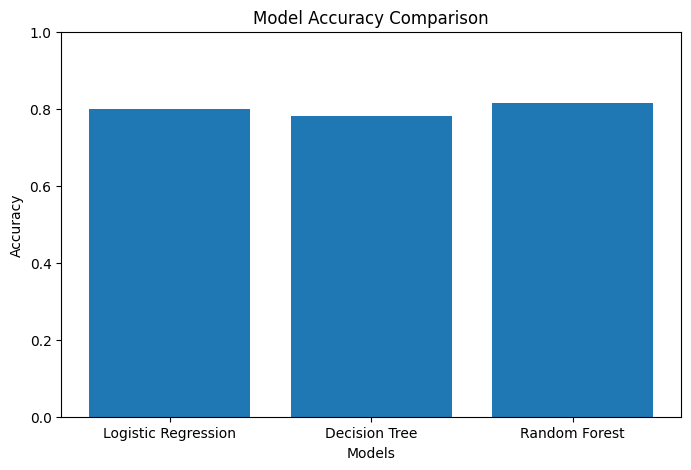

In [48]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracies = [accuracy, tree_accuracy, forest_accuracy]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# 15. Conclusion

In this project, we built a complete machine learning workflow using the Titanic dataset. We loaded and explored the data, visualized important patterns, created new features such as `FamilySize` and `IsAlone`, cleaned and prepared the dataset, and trained three classification models: Logistic Regression, Decision Tree, and Random Forest.

The models were evaluated using accuracy, confusion matrices, and classification reports. The final model comparison helps identify which algorithm performed best for predicting Titanic passenger survival.

### Final Note
This notebook is now organized as a structured machine learning report, making it easier to read, explain, and submit.
